In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import tensorflow as tf
from tensorflow.keras .datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

In [5]:
# Load dataset
(x_train,y_train), (x_test,y_test) = mnist.load_data()

In [9]:
# Define a simple model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Define a simple model
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model   # <-- Ye line add karo

# Create the model
model = create_model()

# Check
print(model)

<Sequential name=sequential_1, built=True>


In [10]:
# train the baseline model
history_baseline = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8601 - loss: 3.4224 - val_accuracy: 0.8898 - val_loss: 0.5942
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9097 - loss: 0.4128 - val_accuracy: 0.9076 - val_loss: 0.3864
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9297 - loss: 0.2901 - val_accuracy: 0.9189 - val_loss: 0.3855
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9347 - loss: 0.2628 - val_accuracy: 0.9362 - val_loss: 0.2773
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9430 - loss: 0.2305 - val_accuracy: 0.9407 - val_loss: 0.2630
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9455 - loss: 0.2188 - val_accuracy: 0.9333 - val_loss: 0.2993
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9491 - loss: 0.2037 - val_accuracy: 0.9412 - val_loss: 0.2479
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9518 - loss: 0

# Normalize the data

In [11]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_norm = create_model()

In [13]:
history_norm = model_norm.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9180 - loss: 0.2882 - val_accuracy: 0.9542 - val_loss: 0.1589
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9618 - loss: 0.1287 - val_accuracy: 0.9645 - val_loss: 0.1190
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9734 - loss: 0.0883 - val_accuracy: 0.9703 - val_loss: 0.1038
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9800 - loss: 0.0664 - val_accuracy: 0.9728 - val_loss: 0.0921
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9848 - loss: 0.0503 - val_accuracy: 0.9735 - val_loss: 0.0905
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9884 - loss: 0.0384 - val_accuracy: 0.9772 - val_loss: 0.0848
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9904 - loss: 0.0313 - val_accuracy: 0.9735 - val_loss: 0.0940
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9921 - loss: 0

In [14]:
test_loss, test_accuracy = model_norm.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.08438816666603088
Test Accuracy: 0.9761999845504761


In [16]:
baseline_loss, baseline_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Baseline Accuracy:", baseline_accuracy)
print("Normalized Accuracy:", test_accuracy)

Baseline Accuracy: 0.9409999847412109
Normalized Accuracy: 0.9761999845504761


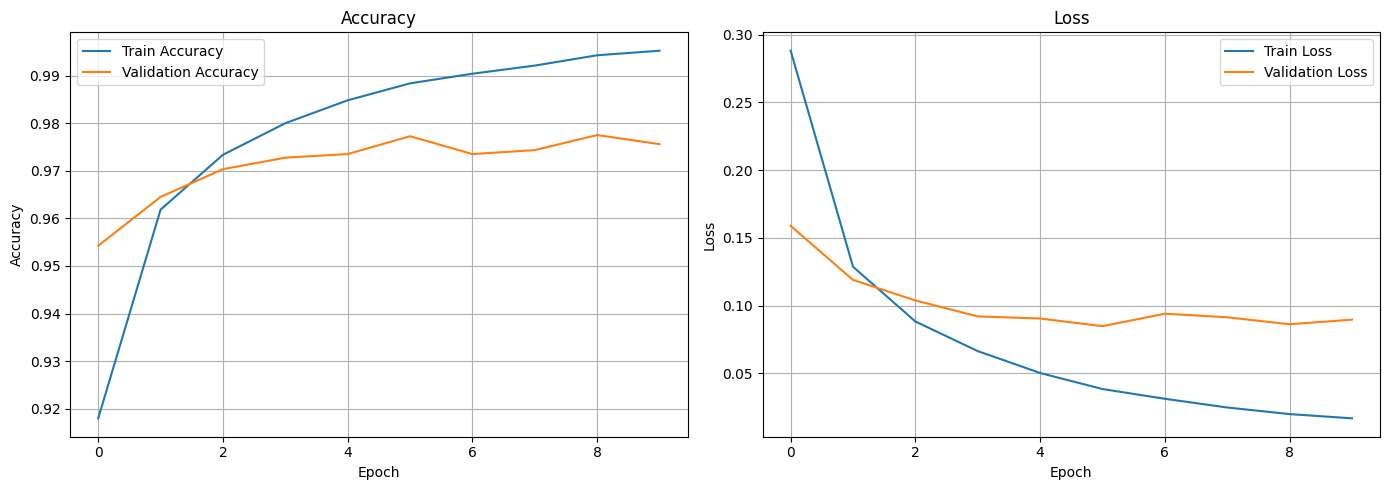

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_norm.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_norm.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_norm.history['loss'], label='Train Loss')
ax[1].plot(history_norm.history['val_loss'], label='Validation Loss')
ax[1].set_title('Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

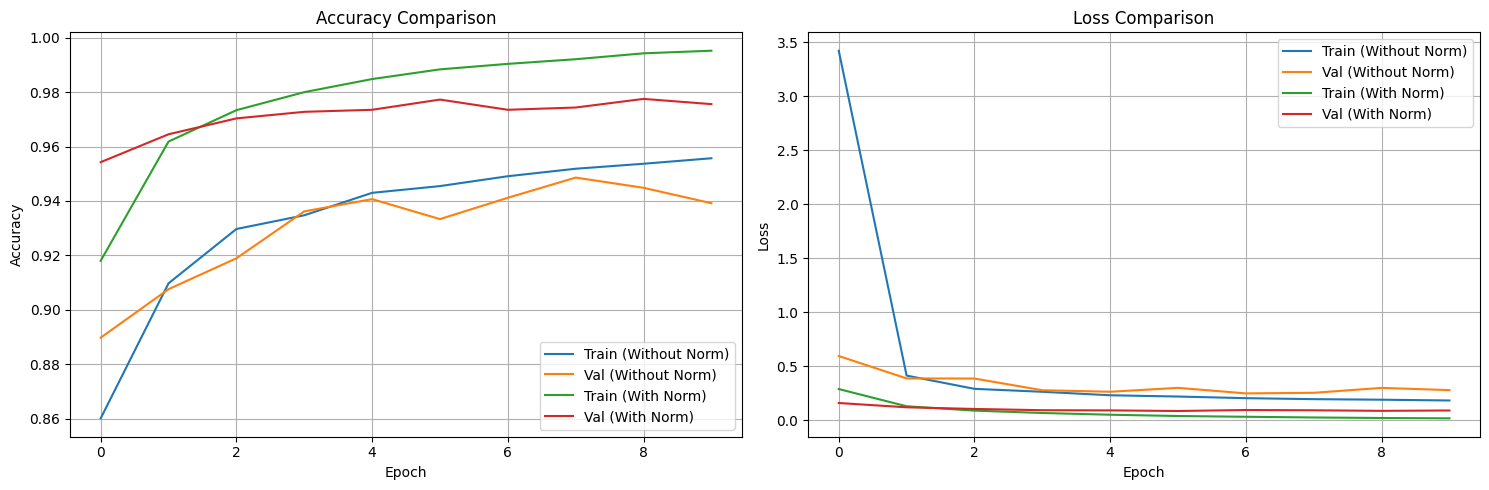

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))

# Accuracy
ax[0].plot(history_baseline.history['accuracy'], label='Train (Without Norm)')
ax[0].plot(history_baseline.history['val_accuracy'], label='Val (Without Norm)')
ax[0].plot(history_norm.history['accuracy'], label='Train (With Norm)')
ax[0].plot(history_norm.history['val_accuracy'], label='Val (With Norm)')
ax[0].set_title("Accuracy Comparison")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_baseline.history['loss'], label='Train (Without Norm)')
ax[1].plot(history_baseline.history['val_loss'], label='Val (Without Norm)')
ax[1].plot(history_norm.history['loss'], label='Train (With Norm)')
ax[1].plot(history_norm.history['val_loss'], label='Val (With Norm)')
ax[1].set_title("Loss Comparison")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()